![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


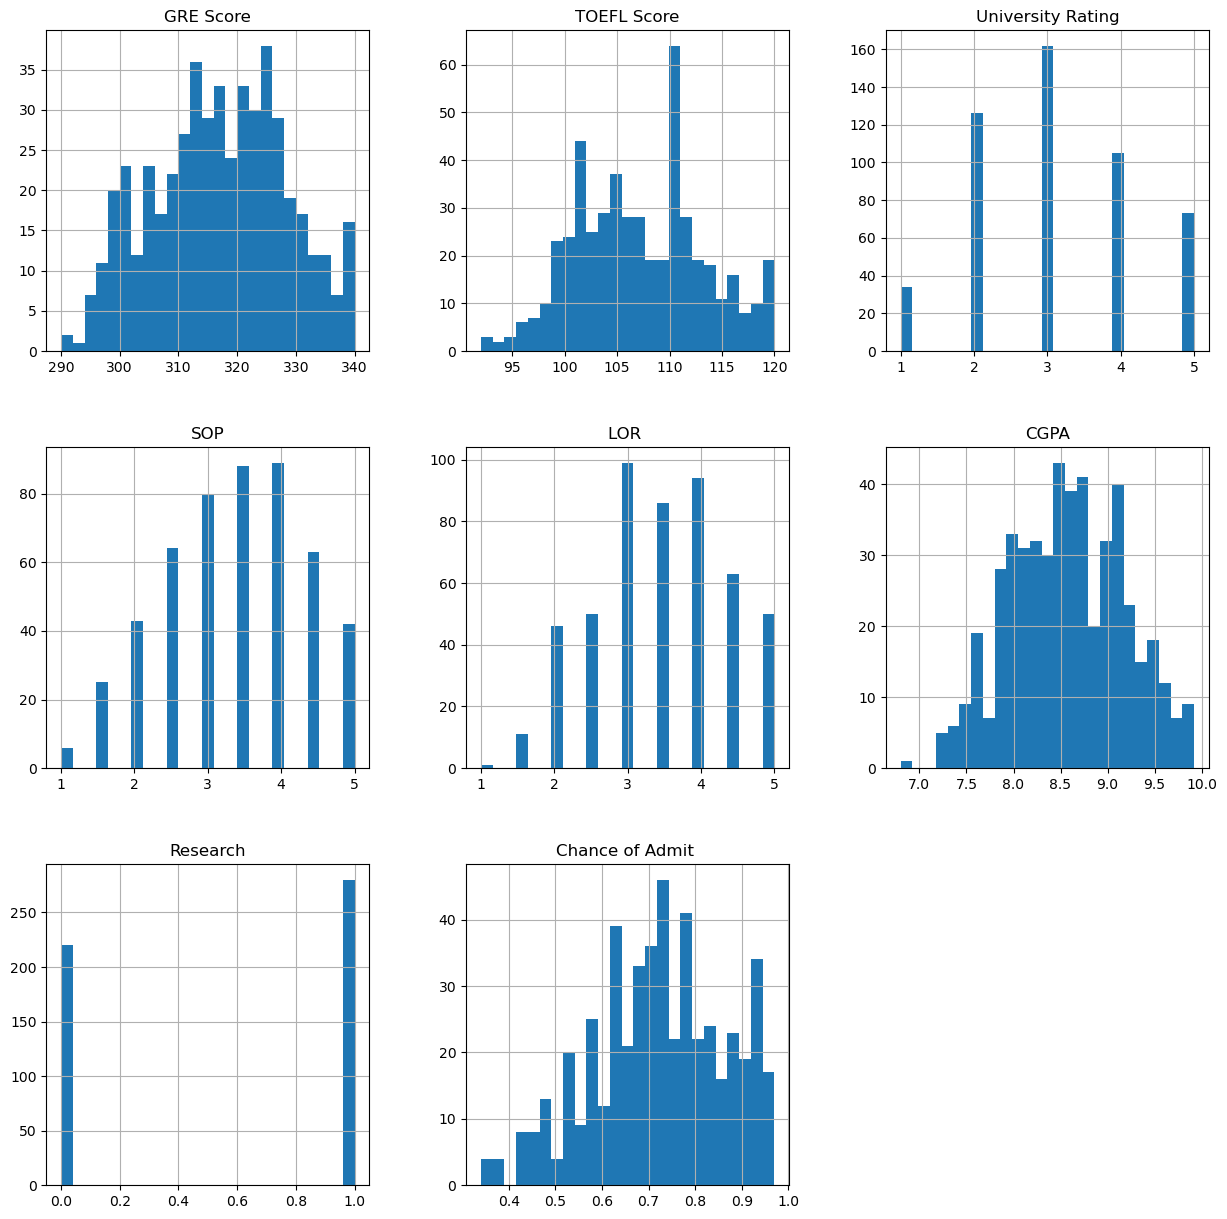

In [4]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [5]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [6]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

### Liberias y Variables de interés y predicción

In [7]:
from keras.optimizers import SGD
from keras import backend as K
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown
from livelossplot import PlotLossesKeras
from keras.callbacks import EarlyStopping
from keras.layers import Dropout


In [8]:
display(Markdown("""
### Estandarización de variables

Antes de entrenar un modelo de redes neuronales, es necesario estandarizar las variables predictoras.  

A continuación, se presentan las estadísticas descriptivas de las variables **antes** y **después** de la estandarización.

"""))
cols = xTrain.columns
display(xTrain.describe())

scaler = StandardScaler()
scaler.fit(xTrain)

xTrain = scaler.transform(xTrain)
xTest = scaler.transform(xTest)

xTrain_scaled_df = pd.DataFrame(xTrain, columns=cols)

# Definición de dimensiones de salida, varaibles de interés
output_var = 1
# Definición de dimensiones de entrada, varaibles predictoras
dims = xTrain.shape[1]

display(xTrain_scaled_df.describe())
display(Markdown(f"""El modelo queda entonces con {output_var} variables de salida y {dims} variables de entrada"""))


### Estandarización de variables

Antes de entrenar un modelo de redes neuronales, es necesario estandarizar las variables predictoras.  

A continuación, se presentan las estadísticas descriptivas de las variables **antes** y **después** de la estandarización.



,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,316.805714,107.414286,3.128571,3.411429,3.507143,8.597057,0.565714
std,11.278296,6.066709,1.149579,0.993178,0.895279,0.591639,0.496372
min,290.000000,92.000000,1.000000,1.000000,1.500000,7.210000,0.000000
25%,309.000000,103.000000,2.000000,2.500000,3.000000,8.142500,0.000000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.570000,1.000000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.060000,1.000000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
count,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02
mean,2.344791e-15,5.481330e-16,-1.015061e-17,-4.567775e-17,4.314009e-17,5.075305e-16,2.791418e-17
std,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00
min,-2.380155e+00,-2.544436e+00,-1.854261e+00,-2.431469e+00,-2.245128e+00,-2.347787e+00,-1.141329e+00
25%,-6.930913e-01,-7.286662e-01,-9.831317e-01,-9.190031e-01,-5.672744e-01,-7.694013e-01,-1.141329e+00
50%,1.725117e-02,-6.838615e-02,-1.120023e-01,8.930751e-02,-7.989780e-03,-4.579798e-02,8.761717e-01
75%,7.275937e-01,7.569639e-01,7.591270e-01,5.934628e-01,5.512948e-01,7.835953e-01,8.761717e-01
max,2.059486e+00,2.077524e+00,1.630256e+00,1.601773e+00,1.669864e+00,2.239265e+00,8.761717e-01


El modelo queda entonces con 1 variables de salida y 7 variables de entrada

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [9]:
# Celda 1
display(Markdown("""
### Calibración y selección de parametros

Se decide realizar una calibración manual de algunos hiperparametros del modelo. En particular
se prueban diferentes valores de:
- Learning rate: en el Stochastic Gradient Descent
- Epochs: veces que el modelo recorre todo el dataset
- Batch size: número de muestras que el modelo usa antes de actualizar pesos               
                 
"""))

# Valores a probar
learning_rates = [0.1, 0.01, 0.001]
epochs_list = [30, 50]
batch_sizes = [128, 256, 512]

results = []

for lr in learning_rates:
    for ep in epochs_list:
        for bs in batch_sizes:
            
            print(f"\nProbando: lr={lr}, epochs={ep}, batch_size={bs}")
            
            K.clear_session()
            
            # Modelo
            model = Sequential()
            model.add(Dense(1, input_shape=(dims,)))
            
            model.compile(
                optimizer=SGD(learning_rate=lr),
                loss='mean_squared_error',
                metrics=['mae']
            )
            
            # Entrenamiento
            history = model.fit(
                xTrain, yTrain,
                validation_split=0.2,
                epochs=ep,
                batch_size=bs,
                verbose=0
            )
            
            # Resultado final
            val_loss = history.history['val_loss'][-1]
            
            results.append((lr, ep, bs, val_loss))
            
            print(f"Val Loss: {val_loss}")

# Encontrar la mejor combinacion

best = min(results, key=lambda x: x[3])
best_lr = best[0]
best_epoch = best[1]
best_batch = best[2]
print("\nMejor configuración encontrada:")
print(f"Learning rate: {best_lr}")
print(f"Epochs: {best_epoch}")
print(f"Batch size: {best_batch}")




### Calibración y selección de parametros

Se decide realizar una calibración manual de algunos hiperparametros del modelo. En particular
se prueban diferentes valores de:
- Learning rate: en el Stochastic Gradient Descent
- Epochs: veces que el modelo recorre todo el dataset
- Batch size: número de muestras que el modelo usa antes de actualizar pesos               




Probando: lr=0.1, epochs=30, batch_size=128

Val Loss: 0.004051500000059605

Probando: lr=0.1, epochs=30, batch_size=256
Val Loss: 0.004367251880466938

Probando: lr=0.1, epochs=30, batch_size=512
Val Loss: 0.0042720334604382515

Probando: lr=0.1, epochs=50, batch_size=128
Val Loss: 0.0038290151860564947

Probando: lr=0.1, epochs=50, batch_size=256
Val Loss: 0.0033558947034180164

Probando: lr=0.1, epochs=50, batch_size=512
Val Loss: 0.009016523137688637

Probando: lr=0.01, epochs=30, batch_size=128
Val Loss: 0.23869001865386963

Probando: lr=0.01, epochs=30, batch_size=256
Val Loss: 0.293486624956131

Probando: lr=0.01, epochs=30, batch_size=512
Val Loss: 0.4488741159439087

Probando: lr=0.01, epochs=50, batch_size=128
Val Loss: 0.03794006630778313

Probando: lr=0.01, epochs=50, batch_size=256
Val Loss: 0.19206024706363678

Probando: lr=0.01, epochs=50, batch_size=512
Val Loss: 0.19436576962471008

Probando: lr=0.001, epochs=30, batch_size=128
Val Loss: 1.5493032932281494

Probando: 

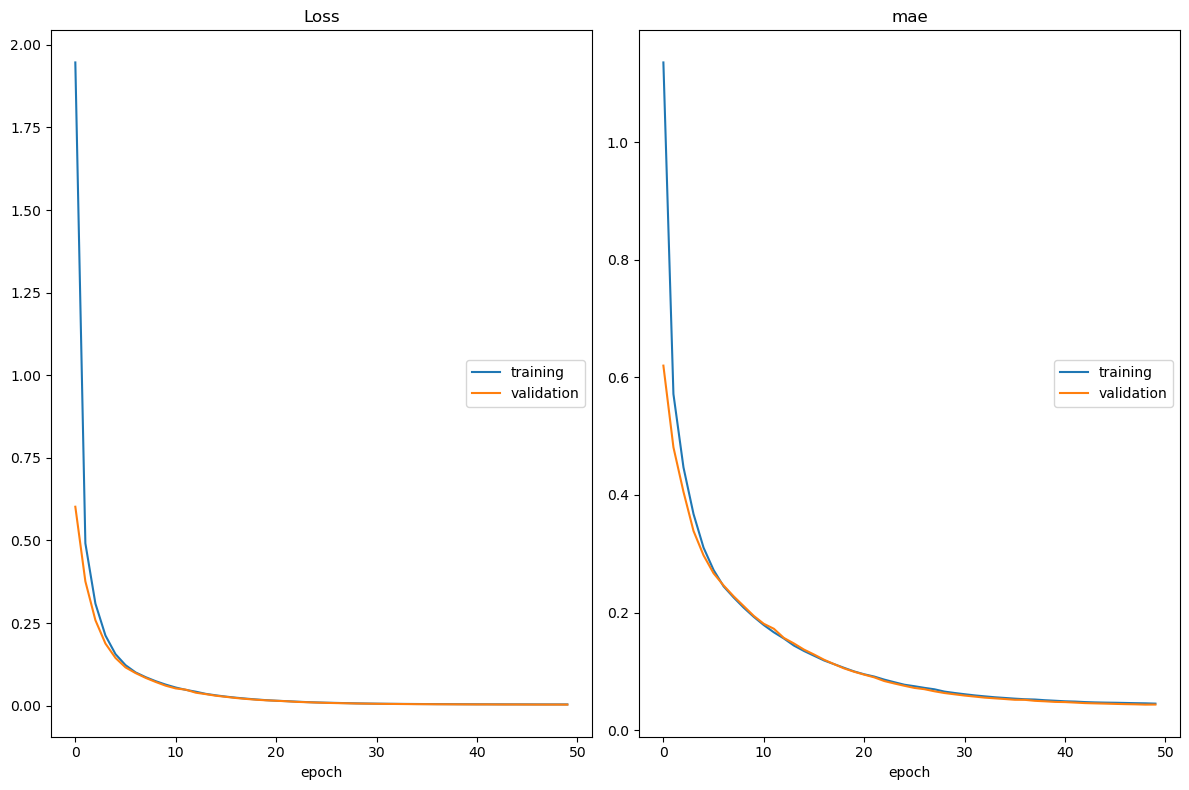

Loss
	training         	 (min:    0.004, max:    1.947, cur:    0.004)
	validation       	 (min:    0.003, max:    0.602, cur:    0.003)
mae
	training         	 (min:    0.045, max:    1.136, cur:    0.045)
	validation       	 (min:    0.043, max:    0.620, cur:    0.043)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 0.0039 - mae: 0.0451 - val_loss: 0.0034 - val_mae: 0.0435



### Desempeño en el conjunto de Test

- **MSE (Mean Squared Error):** 0.00336  
- **MAE (Mean Absolute Error):** 0.04349


In [10]:
display(Markdown("""
#### Mejor modelo             
                 
"""))

K.clear_session()

model = Sequential()
model.add(Dense(output_var, input_shape=(dims,)))
print(model.summary())

model.compile(
    optimizer=SGD(learning_rate=best_lr),
    loss='mean_squared_error',
    metrics=['mae']
)

# Entrenamiento de la red neuronal con 50 epochs
modelo_1 = model.fit(xTrain, yTrain, 
          verbose=True, 
          epochs=best_epoch,
          batch_size=best_batch,
          validation_data=(xTest, yTest),
          callbacks=[PlotLossesKeras()])

# Evaluacion en test
loss_1, mae_1 = model.evaluate(xTest, yTest, verbose=0)

display(Markdown(f"""
### Desempeño en el conjunto de Test

- **MSE (Mean Squared Error):** {loss_1:.5f}  
- **MAE (Mean Absolute Error):** {mae_1:.5f}
"""))

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [11]:
# Celda 2

display(Markdown("""
### Calibración y selección de parámetros - Red neuronal multicapa (2 capas)

Se calibran:
- Learning rate
- Epochs
- Batch size
- Número de neuronas en la capa oculta
"""))

learning_rates = [0.1, 0.01, 0.001]
epochs_list = [30, 50]
batch_sizes = [128, 256, 512]
neurons_list = [128, 256, 512]

results = []

for n in neurons_list:
    for lr in learning_rates:
        for ep in epochs_list:
            for bs in batch_sizes:
                
                print(f"\nProbando: neurons={n}, lr={lr}, epochs={ep}, batch={bs}")
                
                K.clear_session()
                
                model = Sequential()
                model.add(Dense(n, input_shape=(dims,), activation='relu'))
                model.add(Dense(1))
                
                model.compile(
                    optimizer=SGD(learning_rate=lr),
                    loss='mean_squared_error',
                    metrics=['mae']
                )
                
                history = model.fit(
                    xTrain, yTrain,
                    validation_split=0.2,
                    epochs=ep,
                    batch_size=bs,
                    verbose=0
                )
                
                val_loss = min(history.history['val_loss'])
                
                results.append((n, lr, ep, bs, val_loss))
                
                print(f"Val Loss: {val_loss}")
                
best = min(results, key=lambda x: x[4])

best_neurons = best[0]
best_lr = best[1]
best_epoch = best[2]
best_batch = best[3]

print("\nMejor configuración encontrada:")
print(f"Neurons: {best_neurons}")
print(f"Learning rate: {best_lr}")
print(f"Epochs: {best_epoch}")
print(f"Batch size: {best_batch}")


### Calibración y selección de parámetros - Red neuronal multicapa (2 capas)

Se calibran:
- Learning rate
- Epochs
- Batch size
- Número de neuronas en la capa oculta



Probando: neurons=128, lr=0.1, epochs=30, batch=128
Val Loss: 0.0036699464544653893

Probando: neurons=128, lr=0.1, epochs=30, batch=256
Val Loss: 0.006888758856803179

Probando: neurons=128, lr=0.1, epochs=30, batch=512
Val Loss: 0.009879415854811668

Probando: neurons=128, lr=0.1, epochs=50, batch=128
Val Loss: 0.004236306995153427

Probando: neurons=128, lr=0.1, epochs=50, batch=256
Val Loss: 0.005382966715842485

Probando: neurons=128, lr=0.1, epochs=50, batch=512
Val Loss: 0.0067252847366034985

Probando: neurons=128, lr=0.01, epochs=30, batch=128
Val Loss: 0.03363480046391487

Probando: neurons=128, lr=0.01, epochs=30, batch=256
Val Loss: 0.03857595473527908

Probando: neurons=128, lr=0.01, epochs=30, batch=512
Val Loss: 0.07033421099185944

Probando: neurons=128, lr=0.01, epochs=50, batch=128
Val Loss: 0.01786644198000431

Probando: neurons=128, lr=0.01, epochs=50, batch=256
Val Loss: 0.02379778027534485

Probando: neurons=128, lr=0.01, epochs=50, batch=512
Val Loss: 0.05046476

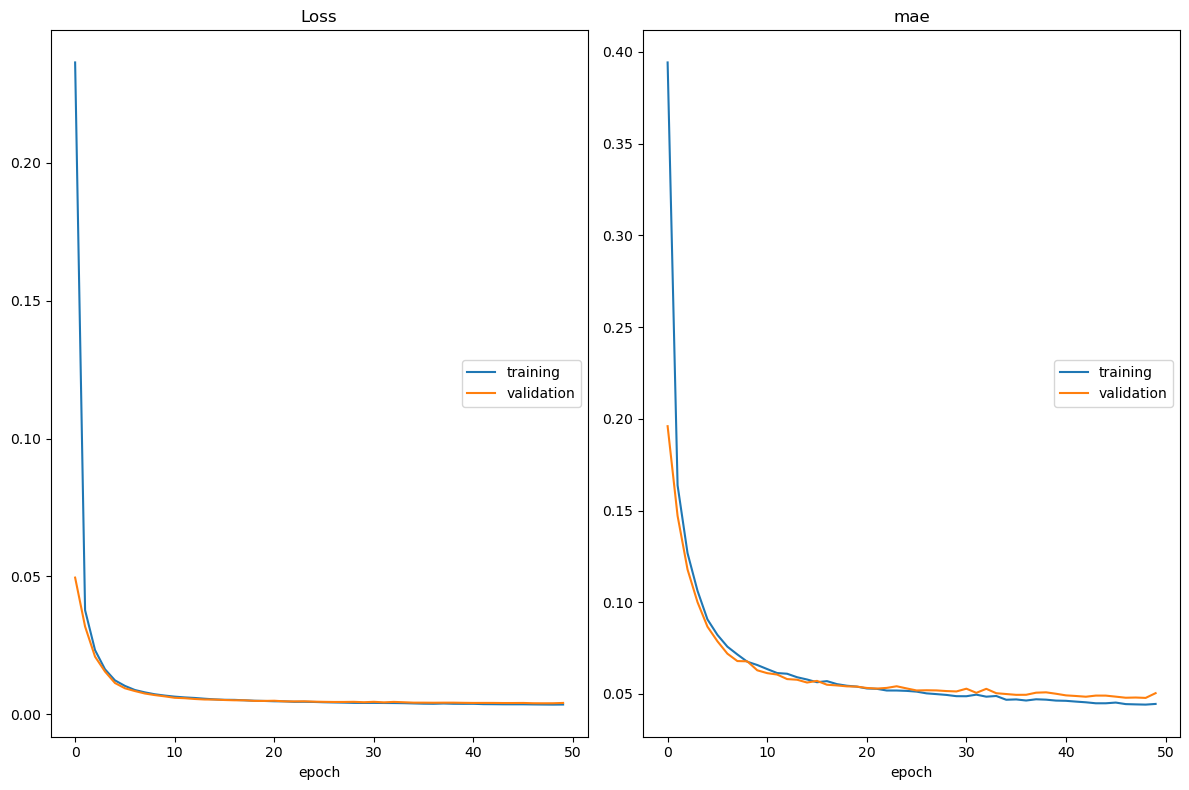

Loss
	training         	 (min:    0.004, max:    0.236, cur:    0.004)
	validation       	 (min:    0.004, max:    0.050, cur:    0.004)
mae
	training         	 (min:    0.044, max:    0.394, cur:    0.045)
	validation       	 (min:    0.048, max:    0.196, cur:    0.050)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.0035 - mae: 0.0446 - val_loss: 0.0041 - val_mae: 0.0505



### Desempeño en el conjunto de Test

- **MSE (Mean Squared Error):** 0.00413  
- **MAE (Mean Absolute Error):** 0.05046

Aunque el modelo multicapa permite capturar relaciones no lineales, en este caso no presenta
una mejora respecto al modelo simple, lo cual puede deberse al tamaño del dataset o a
la complejidad del problema.


In [12]:
display(Markdown("""
#### Mejor modelo - Red neuronal multicapa (2 capas)
"""))

K.clear_session()

model = Sequential()
model.add(Dense(best_neurons, input_shape=(dims,), activation='relu'))  
model.add(Dense(1))

print(model.summary())

# Compilacion con mejores hiperparametros
model.compile(
    optimizer=SGD(learning_rate=best_lr),
    loss='mean_squared_error',
    metrics=['mae']
)

# Entrenamiento final
modelo_2 = model.fit(
    xTrain, yTrain,
    epochs=best_epoch,
    batch_size=best_batch,
    validation_data=(xTest, yTest),
    verbose=1,
    callbacks=[PlotLossesKeras()]
)

loss_2, mae_2 = model.evaluate(xTest, yTest, verbose=0)

display(Markdown(f"""
### Desempeño en el conjunto de Test

- **MSE (Mean Squared Error):** {loss_2:.5f}  
- **MAE (Mean Absolute Error):** {mae_2:.5f}

Aunque el modelo multicapa permite capturar relaciones no lineales, en este caso no presenta
una mejora respecto al modelo simple, lo cual puede deberse al tamaño del dataset o a
la complejidad del problema.
"""))



## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [13]:
# Celda 3

display(Markdown("""
### Calibración Dropout y EarlyStopping
Se parte como base del mejor modelo encontrado en el punto anterior y a partir de ese modelo
se prueba combinaciones de valores para parametros tanto del DropOut como 
del early stopping.
- Dropout_rates: porporcion de neuronas que se "apagan" aleatoreamente
- Patience: epocas que espera sin ver mejora
"""))

dropout_rates = [0.1, 0.2, 0.3]
patience_list = [5, 10, 15]

results = []

for dr in dropout_rates:
    for p in patience_list:
        
        print(f"\nProbando: dropout={dr}, patience={p}")
        
        K.clear_session()
        
        # Modelo base del Punto 2 + regularización
        model = Sequential()
        model.add(Dense(best_neurons, input_shape=(dims,), activation='relu'))
        model.add(Dropout(dr))
        model.add(Dense(best_neurons, activation='relu'))
        model.add(Dropout(dr))
        model.add(Dense(1))
        
        model.compile(
            optimizer=SGD(learning_rate=best_lr),
            loss='mean_squared_error',
            metrics=['mae']
        )
        
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=p,
            restore_best_weights=True,
            verbose=0
        )
        
        history = model.fit(
            xTrain, yTrain,
            validation_split=0.2,
            epochs=best_epoch,          
            batch_size=best_batch,      
            verbose=0,
            callbacks=[early_stop]
        )
        
        val_loss = min(history.history['val_loss'])
        
        results.append((dr, p, val_loss))
        
        print(f"Mejor Val Loss: {val_loss}")

best = min(results, key=lambda x: x[2])

best_dropout = best[0]
best_patience = best[1]
print("\nMejor configuración:")
print(f"Dropout: {best_dropout}")
print(f"Patience: {best_patience}")


### Calibración Dropout y EarlyStopping
Se parte como base del mejor modelo encontrado en el punto anterior y a partir de ese modelo
se prueba combinaciones de valores para parametros tanto del DropOut como 
del early stopping.
- Dropout_rates: porporcion de neuronas que se "apagan" aleatoreamente
- Patience: epocas que espera sin ver mejora



Probando: dropout=0.1, patience=5
Mejor Val Loss: 0.0039764693938195705

Probando: dropout=0.1, patience=10
Mejor Val Loss: 0.0037826886400580406

Probando: dropout=0.1, patience=15
Mejor Val Loss: 0.003378593362867832

Probando: dropout=0.2, patience=5
Mejor Val Loss: 0.006213577929884195

Probando: dropout=0.2, patience=10
Mejor Val Loss: 0.0033993928227573633

Probando: dropout=0.2, patience=15
Mejor Val Loss: 0.0037130312994122505

Probando: dropout=0.3, patience=5
Mejor Val Loss: 0.004102847073227167

Probando: dropout=0.3, patience=10
Mejor Val Loss: 0.004527222365140915

Probando: dropout=0.3, patience=15
Mejor Val Loss: 0.0037577825132757425

Mejor configuración:
Dropout: 0.1
Patience: 15


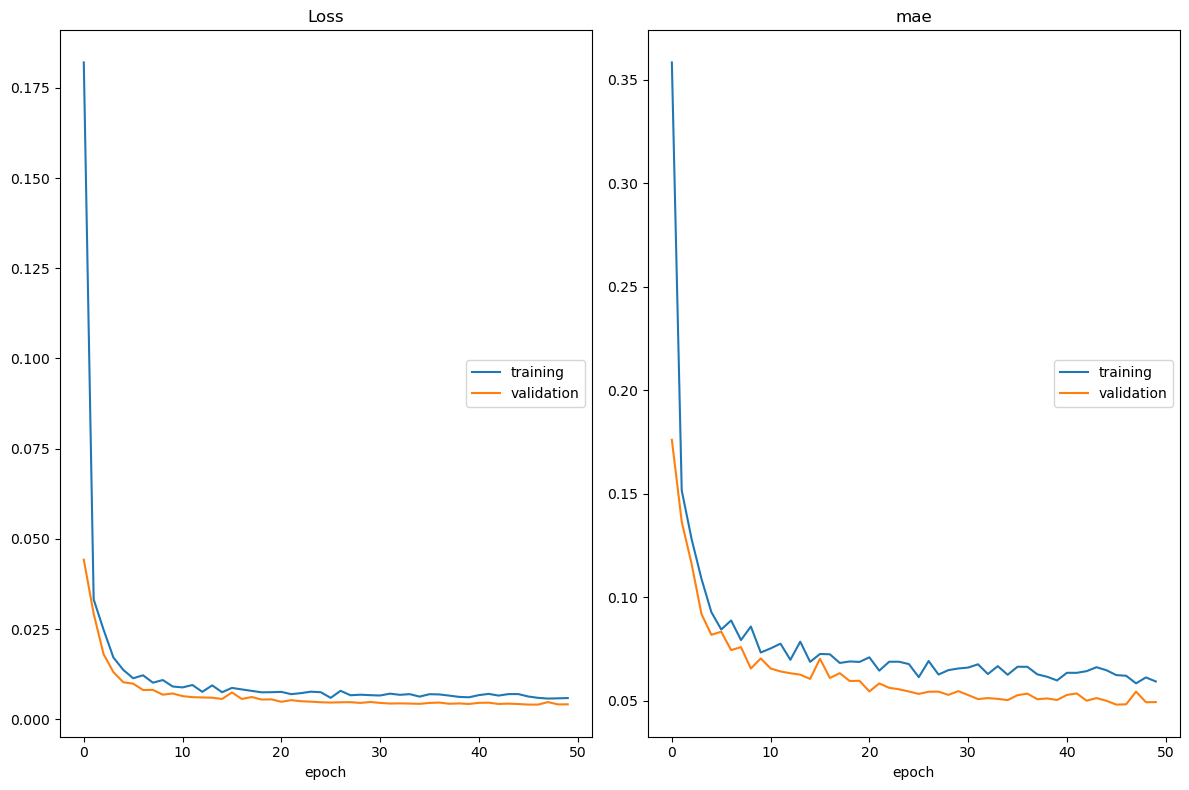

Loss
	training         	 (min:    0.006, max:    0.182, cur:    0.006)
	validation       	 (min:    0.004, max:    0.044, cur:    0.004)
mae
	training         	 (min:    0.058, max:    0.358, cur:    0.059)
	validation       	 (min:    0.048, max:    0.176, cur:    0.049)
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0059 - mae: 0.0592 - val_loss: 0.0041 - val_mae: 0.0493
Restoring model weights from the end of the best epoch: 47.



### Desempeño en test (modelo regularizado)

- MSE: 0.00405  
- MAE: 0.04821


In [14]:
display(Markdown("#### Modelo final con Dropout + EarlyStopping"))

K.clear_session()

model = Sequential()
model.add(Dense(best_neurons, input_shape=(dims,), activation='relu'))
model.add(Dropout(best_dropout))
model.add(Dense(best_neurons, activation='relu'))
model.add(Dropout(best_dropout))
model.add(Dense(1))

model.compile(
    optimizer=SGD(learning_rate=best_lr),
    loss='mean_squared_error',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=best_patience,
    restore_best_weights=True,
    verbose=1
)

modelo_3 = model.fit(
    xTrain, yTrain,
    validation_data=(xTest, yTest),  # mantienes coherencia con tu pipeline
    epochs=best_epoch,
    batch_size=best_batch,
    verbose=1,
    callbacks=[PlotLossesKeras(), early_stop]
)

loss_3, mae_3 = model.evaluate(xTest, yTest, verbose=0)

display(Markdown(f"""
### Desempeño en test (modelo regularizado)

- MSE: {loss_3:.5f}  
- MAE: {mae_3:.5f}
"""))

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

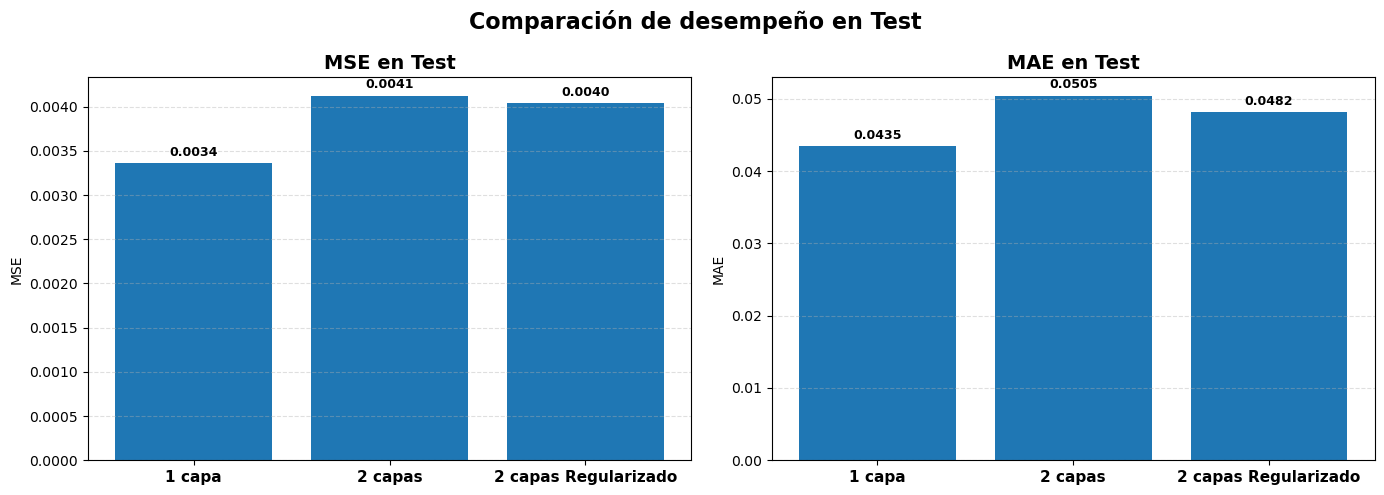

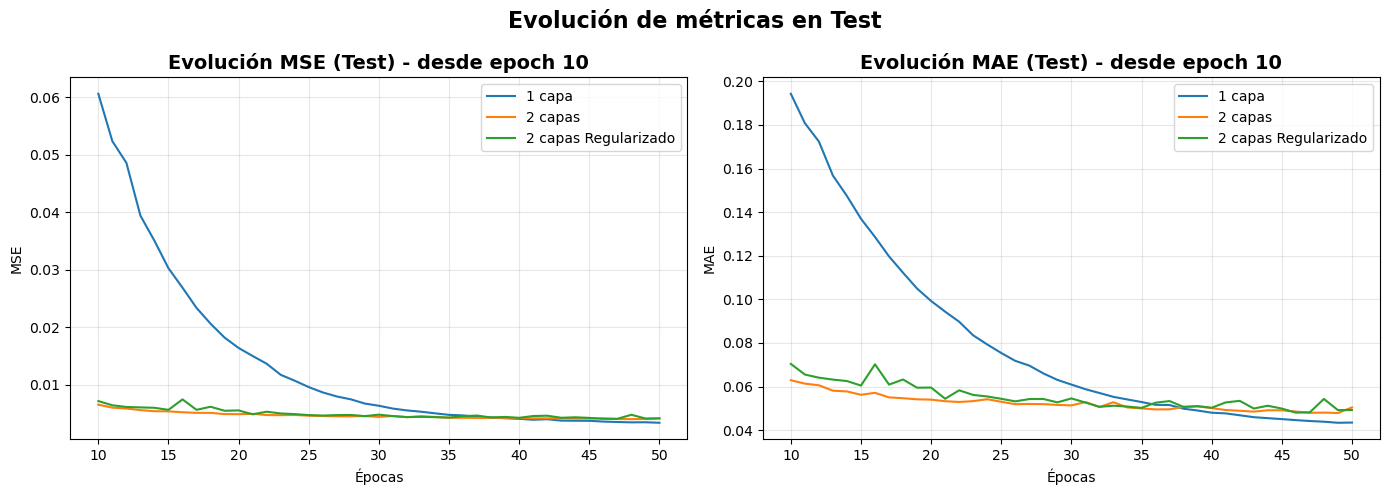

In [24]:

modelos = ['1 capa', '2 capas', '2 capas Regularizado']

mse = [loss_1, loss_2, loss_3]
mae = [mae_1, mae_2, mae_3]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

x = np.arange(len(modelos))

# --- MSE ---
bars1 = axes[0].bar(x, mse)

axes[0].set_title('MSE en Test', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, fontsize=11, fontweight='bold')
axes[0].set_ylabel('MSE')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for rect in bars1:
    height = rect.get_height()
    axes[0].annotate(f'{height:.4f}',
                     xy=(rect.get_x() + rect.get_width()/2, height),
                     xytext=(0,3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9, fontweight='bold')

# --- MAE ---
bars2 = axes[1].bar(x, mae)

axes[1].set_title('MAE en Test', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, fontsize=11, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for rect in bars2:
    height = rect.get_height()
    axes[1].annotate(f'{height:.4f}',
                     xy=(rect.get_x() + rect.get_width()/2, height),
                     xytext=(0,3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9, fontweight='bold')

plt.suptitle('Comparación de desempeño en Test', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14,5))

start_epoch = 9  # época 10

# eje X correcto
epochs_range = range(10, len(modelo_1.history['val_loss']) + 1)

# --- MSE ---
axes[0].plot(epochs_range, modelo_1.history['val_loss'][start_epoch:], label=modelos[0])
axes[0].plot(epochs_range, modelo_2.history['val_loss'][start_epoch:], label=modelos[1])
axes[0].plot(epochs_range, modelo_3.history['val_loss'][start_epoch:], label=modelos[2])

axes[0].set_title('Evolución MSE (Test) - desde epoch 10', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- MAE ---
axes[1].plot(epochs_range, modelo_1.history['val_mae'][start_epoch:], label=modelos[0])
axes[1].plot(epochs_range, modelo_2.history['val_mae'][start_epoch:], label=modelos[1])
axes[1].plot(epochs_range, modelo_3.history['val_mae'][start_epoch:], label=modelos[2])

axes[1].set_title('Evolución MAE (Test) - desde epoch 10', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Evolución de métricas en Test', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()